# 4.3 多层感知机的简洁实现

本节使用 PyTorch 高级 API 实现与 4.2 相同的单隐藏层 MLP。数据加载、训练和评估仍由笔记自行实现，全程不依赖 `d2l`。

原教材：[4.3 多层感知机的简洁实现](https://zh.d2l.ai/chapter_multilayer-perceptrons/mlp-concise.html)

## 学习目标

1. 用 `nn.Sequential`、`nn.Flatten`、`nn.Linear` 和 `nn.ReLU` 组装 MLP；
2. 使用 `apply` 初始化网络参数；
3. 掌握标准 PyTorch 训练与评估模式；
4. 对比从零实现和简洁实现的职责分工。

In [1]:
import sys  # 判断操作系统，以选择合适的数据加载进程数
from pathlib import Path  # 使用面向对象方式管理数据路径

import matplotlib.pyplot as plt  # 绘制训练指标曲线
import torch  # 提供张量计算、自动微分与优化器
import torchvision  # 提供 Fashion-MNIST 等视觉数据集
from torch import nn  # 导入神经网络层、损失函数和参数管理组件
from torch.utils.data import DataLoader  # 将数据集组织成小批量迭代器
from torchvision import transforms  # 提供图片到张量的数据变换

torch.manual_seed(42)  # 固定随机种子，使初始化和抽样结果可复现
batch_size = 256  # 设置每个小批量的样本数
data_root = Path('../data')  # 指定 Fashion-MNIST 的下载与缓存目录
num_workers = 0 if sys.platform.startswith('win') else 2  # Windows 使用主进程加载以避免多进程问题
train_dataset = torchvision.datasets.FashionMNIST(  # 创建训练数据集对象
    root=data_root, train=True, transform=transforms.ToTensor(), download=True  # 下载训练集并将图片转成张量
)  # 完成训练数据集配置
test_dataset = torchvision.datasets.FashionMNIST(  # 创建测试数据集对象
    root=data_root, train=False, transform=transforms.ToTensor(), download=True  # 下载测试集并将图片转成张量
)  # 完成测试数据集配置
train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)  # 打乱训练集并按批读取
test_iter = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)  # 保持测试集顺序并按批读取

## 4.3.1 模型

`nn.Sequential` 按顺序调用其中模块：

$$[B,1,28,28]\xrightarrow{\text{Flatten}}[B,784]\xrightarrow{\text{Linear}}[B,256]\xrightarrow{\text{ReLU}}[B,256]\xrightarrow{\text{Linear}}[B,10].$$

最后一层不放 softmax，因为 `CrossEntropyLoss` 直接接收 logits。

In [2]:
net = nn.Sequential(  # 按前向传播顺序组合各个 nn.Module 网络层
    nn.Flatten(),  # 将 [B,1,28,28] 展平为 [B,784]
    nn.Linear(28 * 28, 256),  # 自动创建第一层权重和偏置并输出 [B,256]
    nn.ReLU(),  # 对隐藏层输出逐元素应用 ReLU 非线性激活
    nn.Linear(256, 10),  # 自动创建第二层参数并输出 10 类 logits
)  # 完成 MLP 网络结构定义

def init_weights(module):  # 定义供 net.apply 逐模块调用的初始化函数
    if isinstance(module, nn.Linear):  # 只初始化带权重和偏置的全连接层
        nn.init.normal_(module.weight, mean=0.0, std=0.01)  # 将权重原地初始化为均值 0、标准差 0.01 的正态随机数
        nn.init.zeros_(module.bias)  # 将偏置原地初始化为 0

net.apply(init_weights)  # 递归访问网络内各模块并执行初始化函数
print(net)  # 输出 Sequential 中各层的结构
print('参数总数:', sum(parameter.numel() for parameter in net.parameters()))  # 通过 nn.Module 自动收集并统计全部参数

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=10, bias=True)
)
参数总数: 203530


### 形状检查与参数访问

高级 API 管理参数并不会隐藏数学结构。`net[1].weight` 对应 $W_1$，但 PyTorch 的 `Linear` 权重布局是 `[输出特征数, 输入特征数]`，前向传播内部计算 $XW^\top+b$。

In [3]:
shape_test = torch.randn(4, 1, 28, 28)  # 构造 4 张单通道 28×28 的随机图片
print('输出形状:', net(shape_test).shape)  # 检查网络是否输出 [4,10] logits
print('第一层权重形状:', net[1].weight.shape)  # [256,784]
print('第二层权重形状:', net[3].weight.shape)  # [10,256]

输出形状: torch.Size([4, 10])
第一层权重形状: torch.Size([256, 784])
第二层权重形状: torch.Size([10, 256])


### 损失与优化器

交叉熵负责稳定地组合 logits、softmax 和负对数似然；SGD 通过 `net.parameters()` 自动取得所有可训练参数。

In [4]:
learning_rate, num_epochs = 0.1, 10  # 设置 SGD 学习率与训练轮数
loss_fn = nn.CrossEntropyLoss()  # 创建适用于多分类 logits 的交叉熵损失函数
optimizer = torch.optim.SGD(net.parameters(), lr=learning_rate)  # 使用 nn.Module 自动登记的全部参数创建优化器

### 完整训练循环

`net.train()` 和 `net.eval()` 会切换模块的训练/推理行为。当前网络中的 Linear 与 ReLU 在两种模式下相同，但形成这个习惯对后续 Dropout 和批量归一化非常重要。

In [5]:
def evaluate_accuracy(model, data_iter):  # 定义模型在指定数据集上的准确率评估函数
    model.eval()  # 将所有 nn.Module 切换为评估模式
    correct, total = 0, 0  # 初始化预测正确数与样本总数
    with torch.no_grad():  # 关闭梯度记录以减少评估时的内存和计算开销
        for X, y in data_iter:  # 逐批读取特征与真实标签
            correct += int((model(X).argmax(dim=1) == y).sum())  # 前向预测并累计分类正确数
            total += y.numel()  # 累加当前批次样本数
    return correct / total  # 返回整个数据集上的分类准确率

def train_model(model, train_iter, test_iter, loss_fn, optimizer, num_epochs):  # 定义完整训练流程
    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}  # 保存各轮指标供绘图使用
    for epoch in range(num_epochs):  # 重复遍历训练集 num_epochs 轮
        model.train()  # 将所有 nn.Module 切回训练模式
        loss_sum, correct, total = 0.0, 0, 0  # 重置本轮损失总和、正确数和样本数
        for X, y in train_iter:  # 逐个小批量训练模型
            optimizer.zero_grad()  # 清除上一批次累积在参数上的梯度
            logits = model(X)  # 调用 Sequential 完成前向传播
            loss = loss_fn(logits, y)  # 计算当前批次的平均交叉熵损失
            loss.backward()  # 自动反向传播并计算所有参数的梯度
            optimizer.step()  # 根据梯度更新 net.parameters() 中的参数
            loss_sum += loss.item() * y.numel()  # 把批平均损失还原为损失总和后累计
            correct += int((logits.argmax(dim=1) == y).sum())  # 累加本批预测正确数
            total += y.numel()  # 累加本批样本数
        history['train_loss'].append(loss_sum / total)  # 计算并记录本轮平均训练损失
        history['train_acc'].append(correct / total)  # 计算并记录本轮训练准确率
        history['test_acc'].append(evaluate_accuracy(model, test_iter))  # 评估并记录本轮测试准确率
        print(f"epoch {epoch + 1:2d}: loss {history['train_loss'][-1]:.4f}, "  # 生成损失与轮次文本
              f"train acc {history['train_acc'][-1]:.3f}, test acc {history['test_acc'][-1]:.3f}")  # 补充并输出准确率文本
    return history  # 返回全部训练历史

history = train_model(net, train_iter, test_iter, loss_fn, optimizer, num_epochs)  # 启动训练并接收指标历史

epoch  1: loss 1.0429, train acc 0.645, test acc 0.762
epoch  2: loss 0.6010, train acc 0.788, test acc 0.788
epoch  3: loss 0.5208, train acc 0.818, test acc 0.767
epoch  4: loss 0.4802, train acc 0.831, test acc 0.819
epoch  5: loss 0.4535, train acc 0.841, test acc 0.794
epoch  6: loss 0.4337, train acc 0.847, test acc 0.822
epoch  7: loss 0.4186, train acc 0.853, test acc 0.820
epoch  8: loss 0.4041, train acc 0.856, test acc 0.839
epoch  9: loss 0.3923, train acc 0.861, test acc 0.838
epoch 10: loss 0.3832, train acc 0.865, test acc 0.845


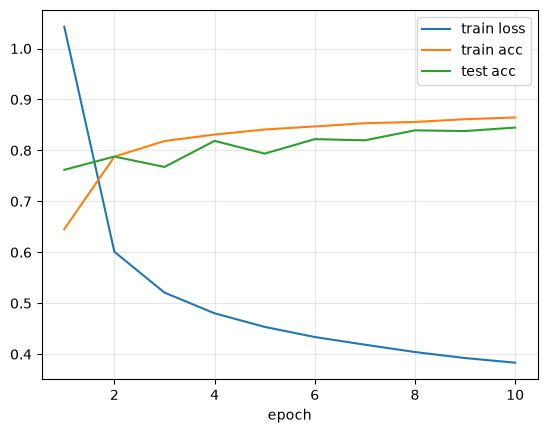

In [6]:
epochs = range(1, num_epochs + 1)  # 生成从 1 开始的训练轮次横坐标
plt.plot(epochs, history['train_loss'], label='train loss')  # 绘制训练损失曲线
plt.plot(epochs, history['train_acc'], label='train acc')  # 绘制训练准确率曲线
plt.plot(epochs, history['test_acc'], label='test acc')  # 绘制测试准确率曲线
plt.xlabel('epoch')  # 设置横轴名称为训练轮次
plt.grid(alpha=0.3)  # 添加半透明网格辅助读数
plt.legend()  # 显示三条曲线的图例
plt.show()  # 在 Notebook 中显示训练曲线

## 从零实现与简洁实现对照

| 职责 | 4.2 从零实现 | 4.3 简洁实现 |
|---|---|---|
| 参数 | `W1, b1, W2, b2` | `nn.Linear` 自动保存 |
| 展平 | `reshape` | `nn.Flatten` |
| 激活 | 手写 `relu` | `nn.ReLU` |
| 组装 | 手写 `net` | `nn.Sequential` |
| 参数遍历 | 手动列表 | `net.parameters()` |

两种实现的数学模型相同。高级 API 的主要价值是可靠地组织层、参数、设备迁移、保存加载以及训练/推理状态。

## 4.3.2 小结

- `nn.Sequential` 可以简洁表达顺序数据流；
- MLP 相比 softmax 回归只是在输出层之前增加了带激活函数的隐藏层；
- 模块自动管理参数，降低深层网络的工程复杂度；
- 模型仍应输出 logits，而不是先调用 softmax。

## 4.3.3 练习

1. 添加不同数量的隐藏层，也可以修改学习率，怎样设置效果最好？
2. 尝试不同激活函数，哪个效果最好？
3. 尝试不同权重初始化方案，什么方法效果最好？

## 4.3.4 练习题参考答案

### 练习 1

应在验证集上公平比较，而不是用测试集选择设置。可比较以下结构：

```python
nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 10))
nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU(),
              nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 10))
```

层数增加会提升容量，同时增加优化难度与过拟合风险。对 Fashion-MNIST，一到两个隐藏层通常已是强基线；学习率需随深度共同搜索。所谓“最好”必须说明验证划分、训练预算和随机种子。

### 练习 2

可将 `nn.ReLU()` 分别换成 `nn.Sigmoid()`、`nn.Tanh()`、`nn.LeakyReLU(0.01)` 或 `nn.GELU()`。ReLU/LeakyReLU 往往比 sigmoid 更易优化，因为正区间不饱和；tanh 比 sigmoid 零中心；GELU 更平滑但计算稍贵。具体优胜者仍需通过验证实验确定。

### 练习 3

不同激活函数适合不同初始化：ReLU/LeakyReLU 常用 Kaiming 初始化，tanh/sigmoid 常用 Xavier 初始化。示例：

```python
def init_kaiming(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
        nn.init.zeros_(module.bias)

def init_xavier(module):
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        nn.init.zeros_(module.bias)
```

初始化过小会使信号和梯度逐层缩小，过大会导致激活或梯度爆炸。当前 ReLU 网络通常首选 Kaiming；但对这个浅网络，默认初始化、标准差 0.01 和 Kaiming 都可能训练良好，应以多随机种子的验证结果判断。